# Step 4 (no-EMG): Cross-animal WBA + WBF plotting

Reads every `summary_<N>ms.csv` file inside a single flat folder, groups them by stimulus duration, and plots cross-animal mean ± SEM of ΔWBF and Normalized WBA.

Expected input layout:

```
<flat_directory>/
    summary_0ms_fly1.csv      ← any filename starting with summary_<N>ms
    summary_0ms_fly2.csv
    summary_3000ms_fly1.csv
    ...
```

Stim duration is parsed as the second underscore-separated token of the file stem (e.g. `summary_3000ms_anything.csv` → `3000ms`).

---

# 第四步（无 EMG 版）：跨个体的 WBA + WBF 绘图

这是不含 EMG／锋电位的精简版第四步。它读取**同一个扁平文件夹**内的每个 `summary_<N>ms.csv` 文件，按刺激时长分组，绘制跨个体的 ΔWBF 与归一化 WBA 的均值 ± SEM（不含发放率、不含栅格）。

预期的输入布局：

```
<扁平文件夹>/
    summary_0ms_fly1.csv      ← 任何以 summary_<N>ms 开头的文件名
    summary_0ms_fly2.csv
    summary_3000ms_fly1.csv
    ...
```

刺激时长由文件名（去扩展名）按下划线分隔的第二个片段解析得到（例如 `summary_3000ms_anything.csv` → `3000ms`）。

**Setup & filename parsing.** Imports, sets the editable-text SVG rcParams (Arial, Affinity-safe), points `flat_directory` at the folder of summary CSVs, and defines `get_stim_color` (red for ChR, green for GtACR) and `parse_stim_duration` (regex that pulls `<N>ms` out of a filename).

**设置与文件名解析。** 导入库，设置可编辑文本的 SVG 参数（Arial、Affinity 友好），将 `flat_directory` 指向汇总 CSV 文件夹，并定义 `get_stim_color`（ChR 为红、GtACR 为绿）与 `parse_stim_duration`（用正则从文件名中提取 `<N>ms`）。

In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300

# Use Arial everywhere and keep SVG text editable (no glyph collapse in Affinity)
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# ---- EDIT ME --------------------------------------------------------------
flat_directory = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/WBA_WBF_only'
# ---------------------------------------------------------------------------

flat_path = Path(flat_directory)

def get_stim_color(directory_path: str) -> str:
    if 'ChR' in directory_path:
        return 'crimson'
    elif 'GtACR' in directory_path:
        return 'lightgreen'
    return 'lightgray'

STIM_RE = re.compile(r'summary_(\d+ms)', re.IGNORECASE)

def parse_stim_duration(file_path: Path) -> str | None:
    m = STIM_RE.search(file_path.stem)
    return m.group(1) if m else None

**Cross-animal WBA + WBF plotting function.** `plot_cross_animal_wba_wbf` loads each animal's summary CSV, windows it, interpolates onto a common time base, pools across animals into mean ± SEM of ΔWBF (left axis) and Normalized WBA as Δ% (right axis) with stimulus shading, and saves the figure as SVG plus the pooled data as CSV.

**跨个体 WBA + WBF 绘图函数。** `plot_cross_animal_wba_wbf` 载入每个个体的汇总 CSV，截取时间窗，插值到共同时间轴，跨个体汇集为 ΔWBF（左轴）与以 Δ% 表示的归一化 WBA（右轴）的均值 ± SEM 并叠加刺激阴影，再将图保存为 SVG、汇集数据保存为 CSV。

In [5]:
def plot_cross_animal_wba_wbf(stim_files: list, time_window=(-2, 10), save_fig=True) -> None:
    """Cross-animal mean ± SEM of ΔWBF and Normalized WBA (no spike rate, no raster)."""
    stim_color = get_stim_color(str(flat_path))

    # Load and window each file
    all_dfs = []
    for f in stim_files:
        df = pd.read_csv(f)
        mask = (df['Time (s)'] >= time_window[0]) & (df['Time (s)'] <= time_window[1])
        all_dfs.append(df.loc[mask].copy())

    # Interpolate to a common timebase
    time = np.linspace(time_window[0], time_window[1], 1000)
    interpolated = []
    for df in all_dfs:
        interp = pd.DataFrame({'Time (s)': time})
        for col in df.columns:
            if col == 'Time (s)':
                continue
            interp[col] = np.interp(time, df['Time (s)'], df[col])
        interpolated.append(interp)

    # Pool across animals
    combined = pd.DataFrame({'Time (s)': time})
    metrics = ['Mean Delta Wingbeat Frequency', 'Mean Normalized Wing Beat Amplitude']
    for metric in metrics:
        values = np.array([df[metric] for df in interpolated if metric in df.columns])
        if values.size == 0:
            continue
        combined[metric] = np.nanmean(values, axis=0)
        sem_name = f'SEM {metric.split("Mean ")[-1]}'
        combined[sem_name] = np.nanstd(values, axis=0) / np.sqrt(len(values))

    if 'Opto Stimulus' in interpolated[0].columns:
        combined['Opto Stimulus'] = interpolated[0]['Opto Stimulus']
    else:
        combined['Opto Stimulus'] = 0

    stim_duration = parse_stim_duration(stim_files[0])
    n_animals = len(all_dfs)

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(12, 5), dpi=300)
    ax1.grid(False)

    # ΔWBF (blue)
    wbf_mean = combined['Mean Delta Wingbeat Frequency']
    wbf_sem = combined['SEM Delta Wingbeat Frequency']
    ax1.plot(time, wbf_mean, color='royalblue', label='ΔWBF')
    ax1.fill_between(time, wbf_mean - wbf_sem, wbf_mean + wbf_sem,
                     color='royalblue', alpha=0.2, linewidth=0)
    ax1.set_ylabel('ΔWBF (Hz)', color='royalblue')
    ax1.tick_params(axis='y', labelcolor='royalblue')
    ax1.set_ylim(-100, 30)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax1.set_xlabel('Time from stimulus onset (s)')
    ax1.set_xlim(time_window)

    # Normalized WBA (orange) on twin axis
    ax1_amp = None
    if 'Mean Normalized Wing Beat Amplitude' in combined.columns:
        ax1_amp = ax1.twinx()
        ax1_amp.grid(False)
        wba_mean = combined['Mean Normalized Wing Beat Amplitude'] - 100
        wba_sem = combined['SEM Normalized Wing Beat Amplitude']
        ax1_amp.plot(time, wba_mean, color='orange', label='Normalized WBA (Δ%)')
        ax1_amp.fill_between(time, wba_mean - wba_sem, wba_mean + wba_sem,
                             color='orange', alpha=0.2, linewidth=0)
        ax1_amp.set_ylabel('Normalized WBA (Δ%)', color='orange')
        ax1_amp.tick_params(axis='y', labelcolor='orange')
        ax1_amp.set_ylim(-60, 20)

    # Stimulus shading
    ymin, ymax = ax1.get_ylim()
    ax1.fill_between(time, ymin, ymax,
                     where=combined['Opto Stimulus'] > 0,
                     color=stim_color, alpha=0.3, linewidth=0)

    # Legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = (ax1_amp.get_legend_handles_labels() if ax1_amp is not None else ([], []))
    ax1.legend(h1 + h2, l1 + l2, loc='upper right')

    fig.suptitle(f"{stim_duration}  (n={n_animals} animals)", y=0.98)
    fig.tight_layout()

    if save_fig:
        svg_path = flat_path / f'summary_across_animals_noEMG_{stim_duration}.svg'
        csv_path = flat_path / f'summary_across_animals_noEMG_{stim_duration}.csv'
        fig.savefig(svg_path, format='svg', bbox_inches='tight')
        combined.to_csv(csv_path, index=False)
        print(f'Saved {svg_path.name} and {csv_path.name}')

    plt.show()

**Discover, group, and plot.** Finds all `summary_*ms*.csv` files in the flat folder, groups them by stimulus duration, prints what was found, and calls the plotting function for each duration.

**发现、分组并绘图。** 找出扁平文件夹中的所有 `summary_*ms*.csv` 文件，按刺激时长分组，打印发现的文件，并对每个时长调用上面的绘图函数。

Found 30 summary CSV files in /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/WBA_WBF_only

0ms: 15 files
    250307_spMN4_ChR_EMG_Fly2_Y_summary_0ms.csv
    250307_spMN4_ChR_EMG_Fly3_Y_summary_0ms.csv
    250318_spMN4_ChR_EMG_Fly1_Y_summary_0ms.csv
    250321_spMN4_ChR_EMG_Fly1_Y_summary_0ms.csv
    250718_spMN4_ChR_Fly1_Y_summary_0ms.csv
    250718_spMN4_ChR_Fly2_Y_summary_0ms.csv
    250718_spMN4_ChR_Fly3_Y_summary_0ms.csv
    250718_spMN4_ChR_Fly4_Y_summary_0ms.csv
    251226_spMN4_ChR_EMG_Fly1_Y_summary_0ms.csv
    251226_spMN4_ChR_EMG_Fly2_Y_summary_0ms.csv
    251226_spMN4_ChR_EMG_Fly3_Y_summary_0ms.csv
    260511_spMN4_ChR_EMG_Fly1_Y_summary_0ms.csv
    260511_spMN4_ChR_EMG_Fly2_Y_summary_0ms.csv
    260511_spMN4_ChR_EMG_Fly3_Y_summary_0ms.csv
    260511_spMN4_ChR_EMG_Fly4_Y_summary_0ms.csv
Saved summary_across_animals_noEM

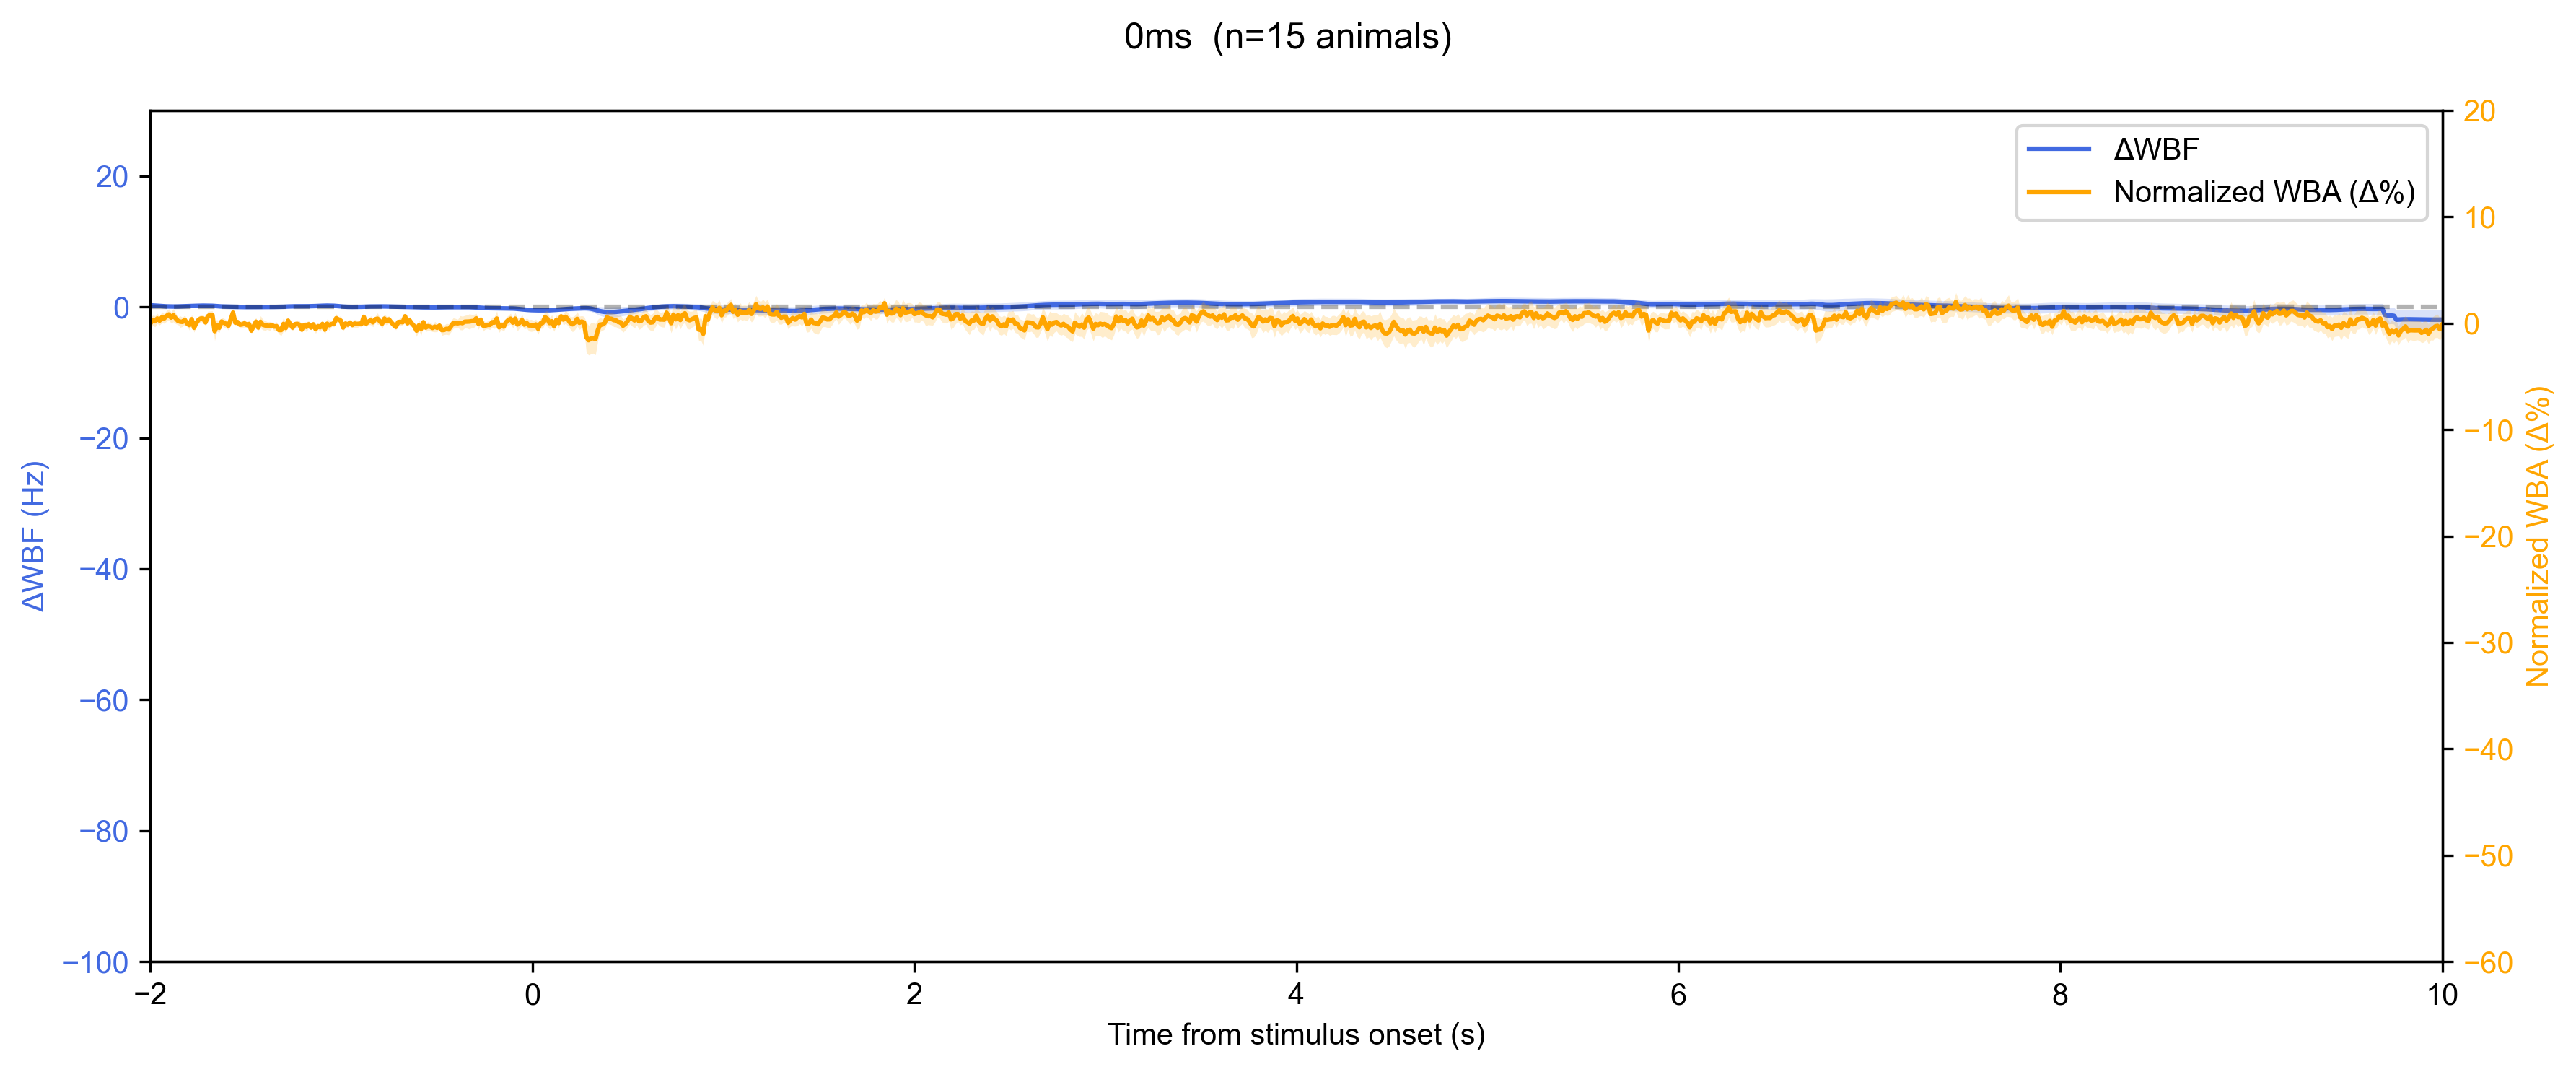


3000ms: 15 files
    250307_spMN4_ChR_EMG_Fly2_Y_summary_3000ms.csv
    250307_spMN4_ChR_EMG_Fly3_Y_summary_3000ms.csv
    250318_spMN4_ChR_EMG_Fly1_Y_summary_3000ms.csv
    250321_spMN4_ChR_EMG_Fly1_Y_summary_3000ms.csv
    250718_spMN4_ChR_Fly1_Y_summary_3000ms.csv
    250718_spMN4_ChR_Fly2_Y_summary_3000ms.csv
    250718_spMN4_ChR_Fly3_Y_summary_3000ms.csv
    250718_spMN4_ChR_Fly4_Y_summary_3000ms.csv
    251226_spMN4_ChR_EMG_Fly1_Y_summary_3000ms.csv
    251226_spMN4_ChR_EMG_Fly2_Y_summary_3000ms.csv
    251226_spMN4_ChR_EMG_Fly3_Y_summary_3000ms.csv
    260511_spMN4_ChR_EMG_Fly1_Y_summary_3000ms.csv
    260511_spMN4_ChR_EMG_Fly2_Y_summary_3000ms.csv
    260511_spMN4_ChR_EMG_Fly3_Y_summary_3000ms.csv
    260511_spMN4_ChR_EMG_Fly4_Y_summary_3000ms.csv
Saved summary_across_animals_noEMG_3000ms.svg and summary_across_animals_noEMG_3000ms.csv


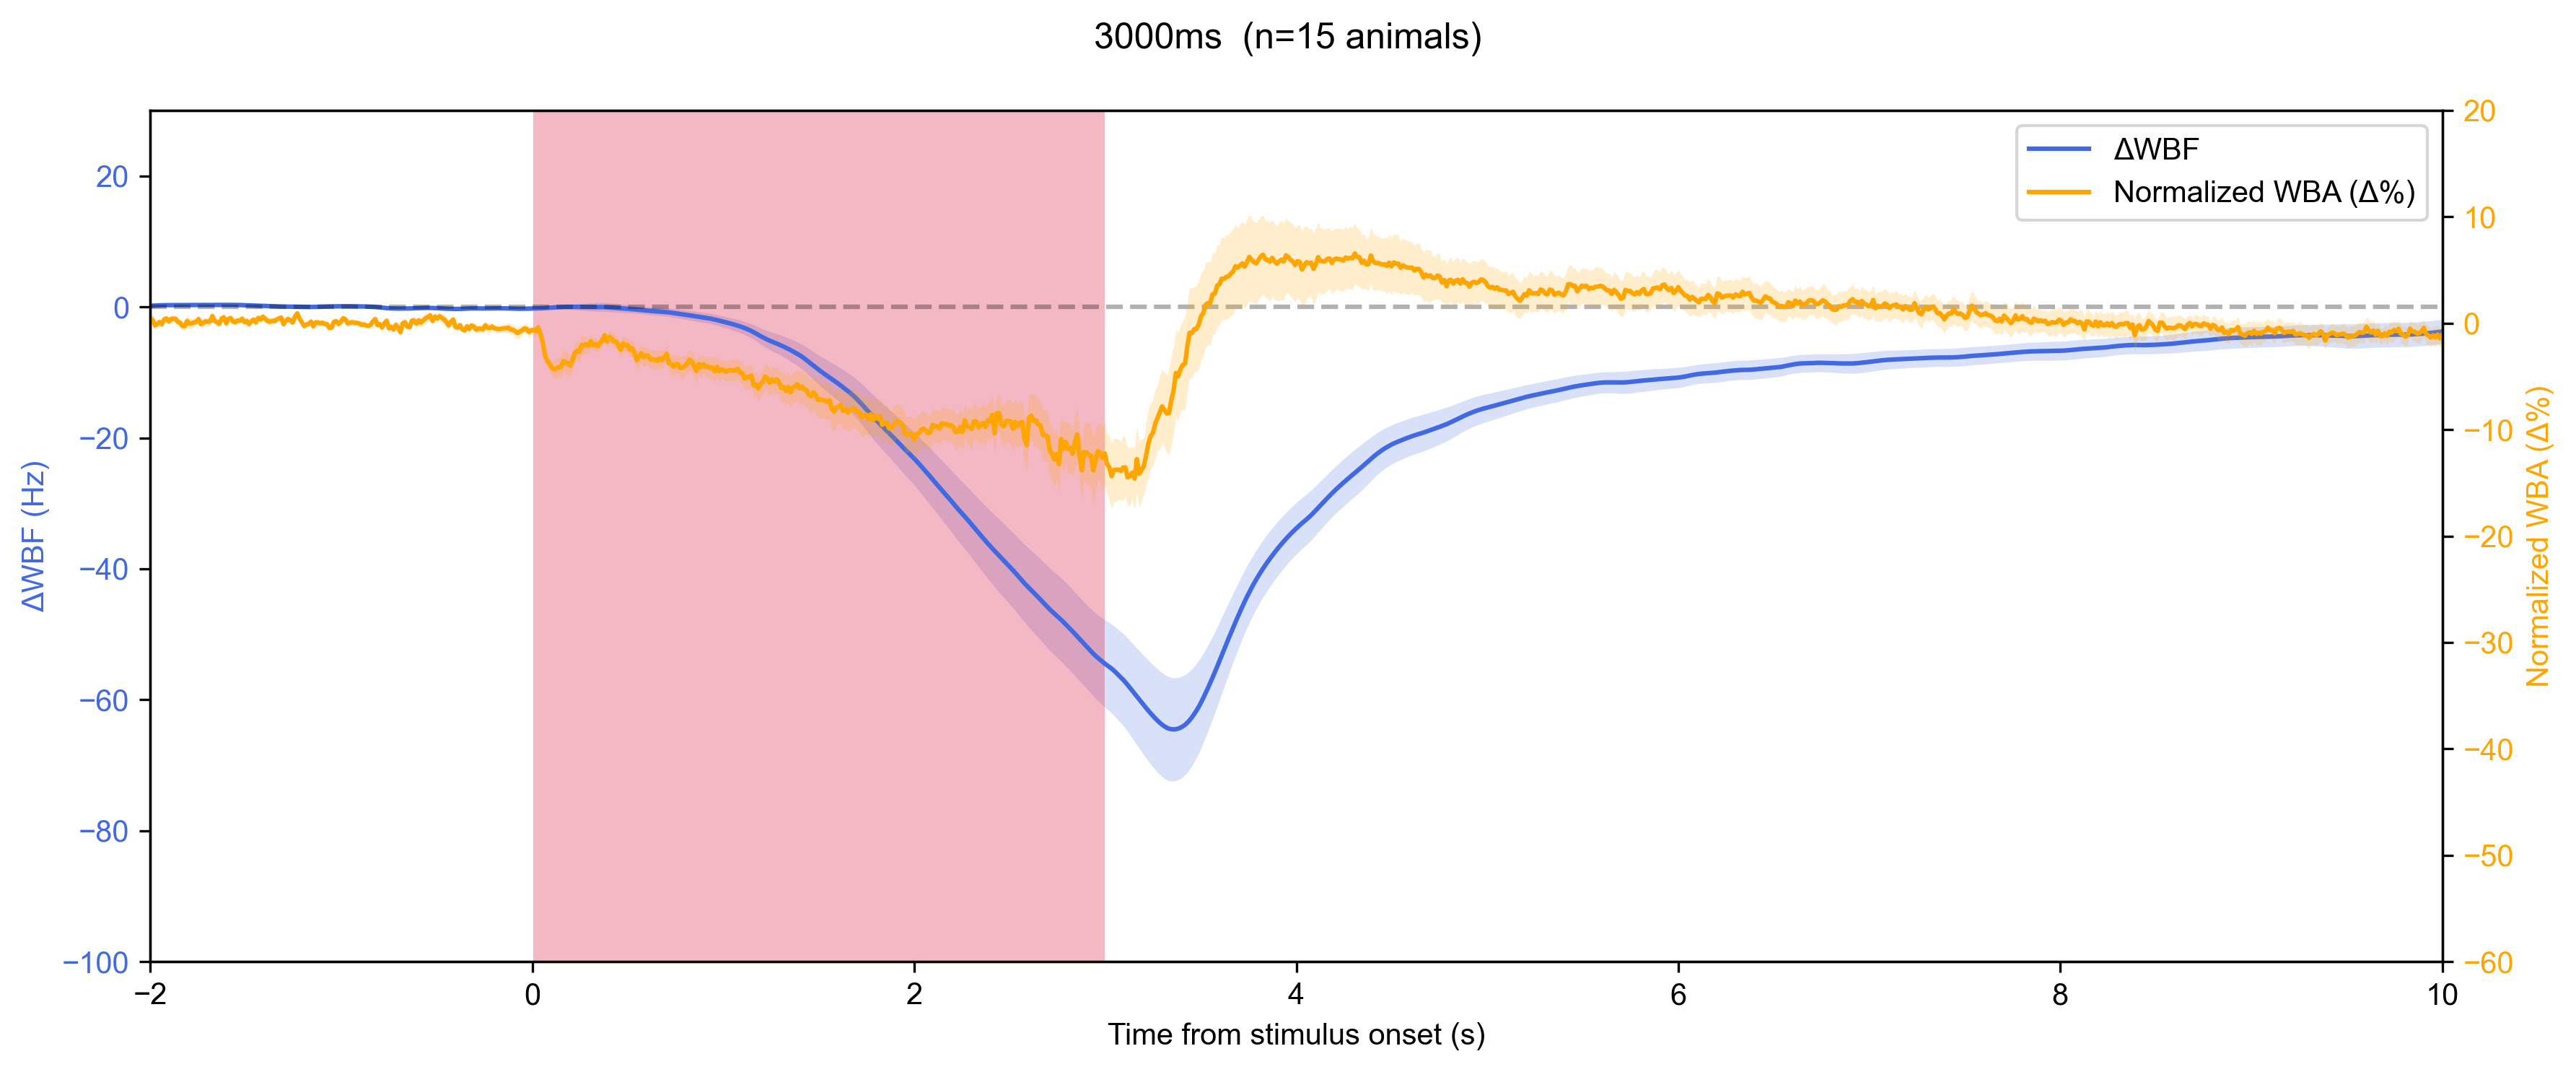

In [7]:
# Discover all summary CSVs in the flat folder and group by stim duration
summary_files = sorted(flat_path.glob('*summary_*ms*.csv'))
print(f'Found {len(summary_files)} summary CSV files in {flat_path}')

summary_by_duration: dict[str, list[Path]] = {}
for f in summary_files:
    stim = parse_stim_duration(f)
    if stim is None:
        print(f'  [skipped] could not parse stim duration: {f.name}')
        continue
    summary_by_duration.setdefault(stim, []).append(f)

stim_durations = sorted(summary_by_duration.keys(),
                        key=lambda x: int(x.rstrip('ms').rstrip('mM').rstrip('sS')))

for stim in stim_durations:
    files = summary_by_duration[stim]
    print(f'\n{stim}: {len(files)} files')
    for f in files:
        print(f'    {f.name}')
    plot_cross_animal_wba_wbf(files, time_window=(-2, 10))